# Statistical Evaluation<hr style = "border:2.5px solid rgba(21, 6, 225, 1)"></hr>


<b> Jeremy Lloyd L. Vallejera </b>
<br> Computer Engineering Technology

In [1]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [2]:
# load dataset
df = pd.read_csv(r"csv\wine-quality-white-and-red.csv", delimiter=",")
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
# summary of statistics
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# Data Cleaning

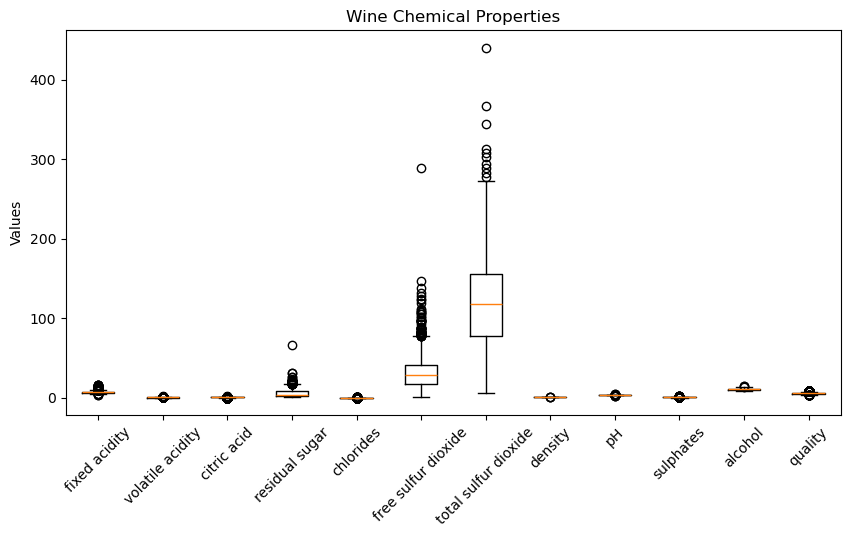

In [5]:
# check for outliers
plt.figure(figsize=(10,5))
plt.boxplot(df[['fixed acidity','volatile acidity','citric acid','residual sugar',
                'chlorides','free sulfur dioxide','total sulfur dioxide',
                'density','pH','sulphates','alcohol','quality']],
            tick_labels=['fixed acidity','volatile acidity','citric acid',
                         'residual sugar','chlorides','free sulfur dioxide',
                         'total sulfur dioxide','density','pH',
                         'sulphates','alcohol','quality'])
plt.title('Wine Chemical Properties')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()

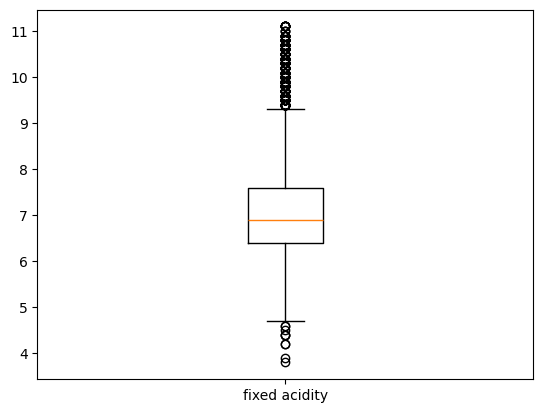

In [6]:
# fixed acidity
# removing 3-sigma outliers
z_fixed_acidity = stats.zscore(df['fixed acidity'])
fixed_acidity_outliers = (z_fixed_acidity < -3) | (z_fixed_acidity > 3)
df = df[~fixed_acidity_outliers]

plt.boxplot(df['fixed acidity'], tick_labels=['fixed acidity'])
plt.show()

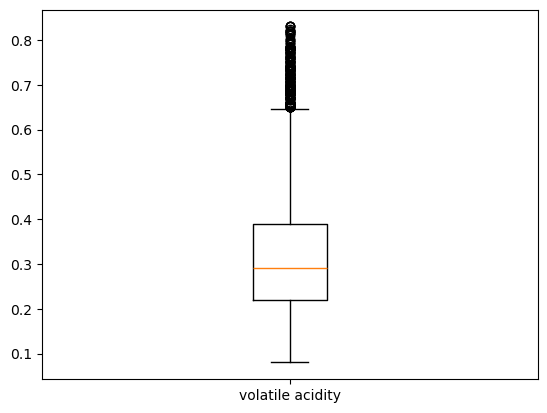

In [7]:
# volatile acidity
# removing 3-sigma outliers
z_volatile_acidity = stats.zscore(df['volatile acidity'])
volatile_acidity_outliers = (z_volatile_acidity < -3) | (z_volatile_acidity > 3)
df = df[~volatile_acidity_outliers]

plt.boxplot(df['volatile acidity'], tick_labels=['volatile acidity'])
plt.show()

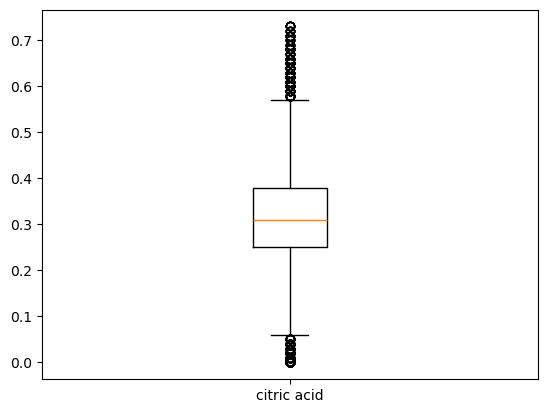

In [8]:
# citric acid
# removing 3-sigma outliers
z_citric_acid = stats.zscore(df['citric acid'])
citric_acid_outliers = (z_citric_acid < -3) | (z_citric_acid > 3)
df = df[~citric_acid_outliers]

plt.boxplot(df['citric acid'], tick_labels=['citric acid'])
plt.show()

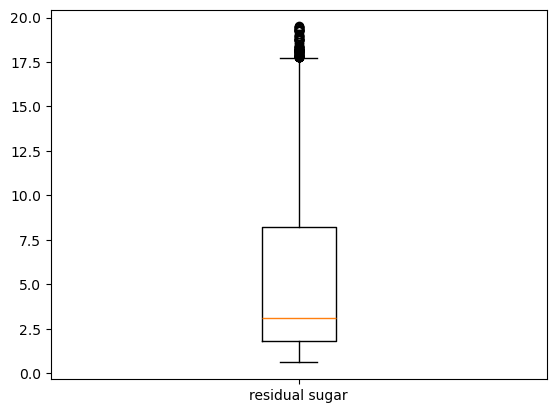

In [9]:
# residual sugar
# removing 3-sigma outliers
z_residual_sugar = stats.zscore(df['residual sugar'])
residual_sugar_outliers = (z_residual_sugar < -3) | (z_residual_sugar > 3)
df = df[~residual_sugar_outliers]

plt.boxplot(df['residual sugar'], tick_labels=['residual sugar'])
plt.show()

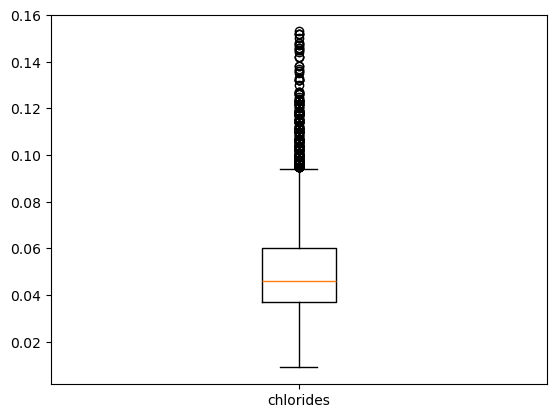

In [10]:
# chlorides
# removing 3-sigma outliers
z_chlorides = stats.zscore(df['chlorides'])
chlorides_outliers = (z_chlorides < -3) | (z_chlorides > 3)
df = df[~chlorides_outliers]

plt.boxplot(df['chlorides'], tick_labels=['chlorides'])
plt.show()

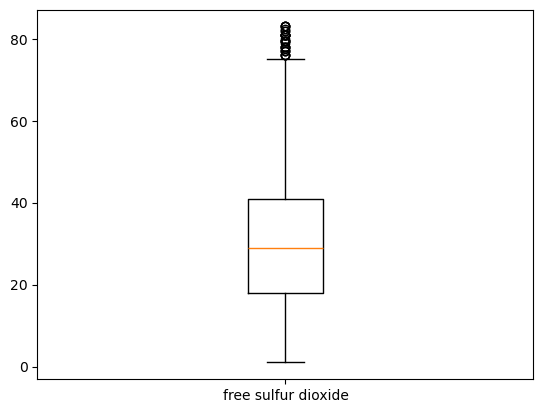

In [11]:
# free sulfur dioxide
# removing 3-sigma outliers
z_free_sulfur = stats.zscore(df['free sulfur dioxide'])
free_sulfur_outliers = (z_free_sulfur < -3) | (z_free_sulfur > 3)
df = df[~free_sulfur_outliers]

plt.boxplot(df['free sulfur dioxide'], tick_labels=['free sulfur dioxide'])
plt.show()

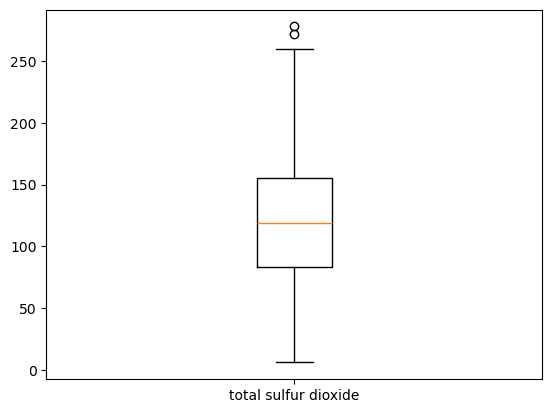

In [12]:
# total sulfur dioxide
# removing 3-sigma outliers
z_total_sulfur = stats.zscore(df['total sulfur dioxide'])
total_sulfur_outliers = (z_total_sulfur < -3) | (z_total_sulfur > 3)
df = df[~total_sulfur_outliers]

plt.boxplot(df['total sulfur dioxide'], tick_labels=['total sulfur dioxide'])
plt.show()

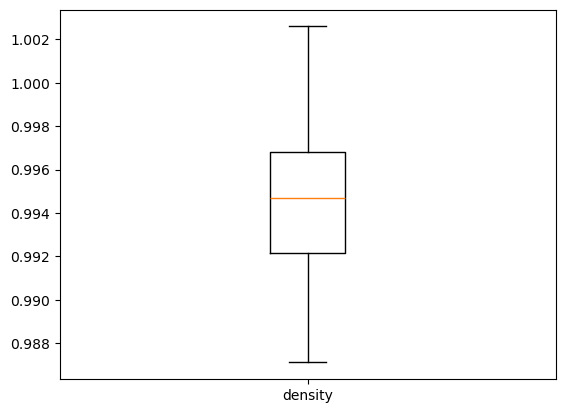

In [13]:
# density
# removing 3-sigma outliers
z_density = stats.zscore(df['density'])
density_outliers = (z_density < -3) | (z_density > 3)
df = df[~density_outliers]

plt.boxplot(df['density'], tick_labels=['density'])
plt.show()

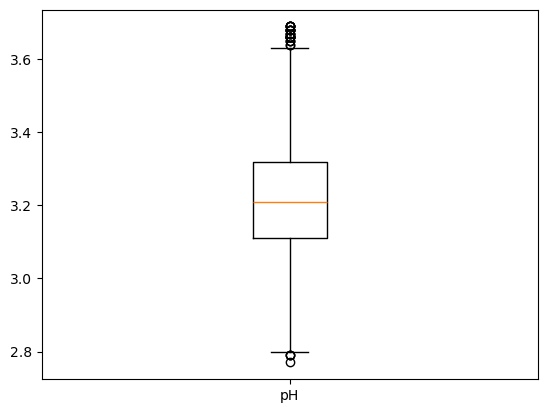

In [14]:
# pH
# removing 3-sigma outliers
z_ph = stats.zscore(df['pH'])
ph_outliers = (z_ph < -3) | (z_ph > 3)
df = df[~ph_outliers]

plt.boxplot(df['pH'], tick_labels=['pH'])
plt.show()

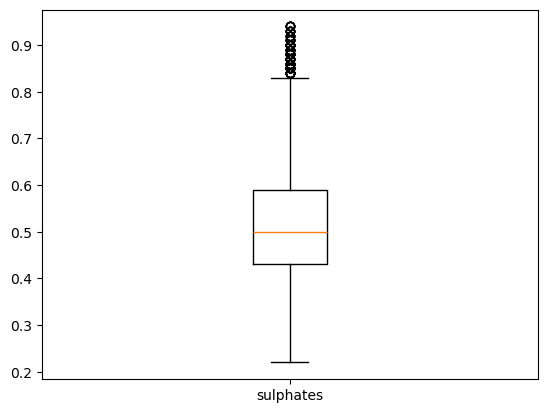

In [15]:
# sulphates
# removing 3-sigma outliers
z_sulphates = stats.zscore(df['sulphates'])
sulphates_outliers = (z_sulphates < -3) | (z_sulphates > 3)
df = df[~sulphates_outliers]

plt.boxplot(df['sulphates'], tick_labels=['sulphates'])
plt.show()

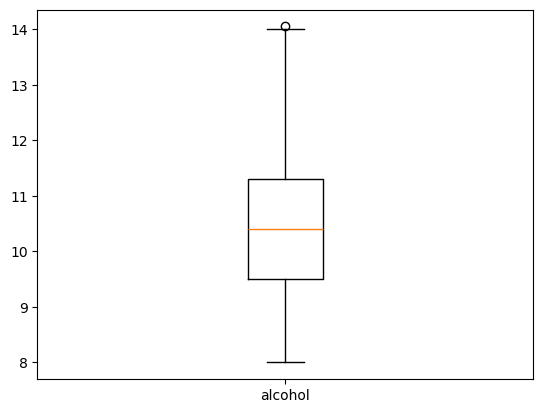

In [16]:
# alcohol
# removing 3-sigma outliers
z_alcohol = stats.zscore(df['alcohol'])
alcohol_outliers = (z_alcohol < -3) | (z_alcohol > 3)
df = df[~alcohol_outliers]

plt.boxplot(df['alcohol'], tick_labels=['alcohol'])
plt.show()

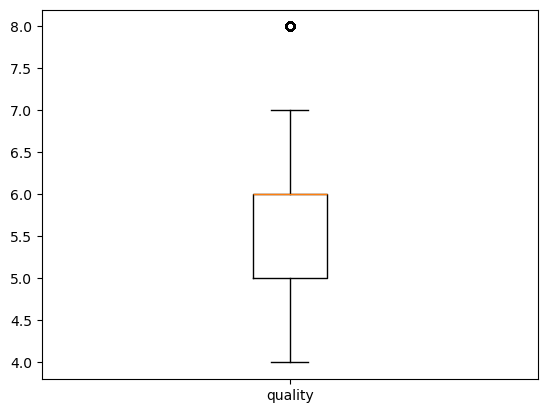

In [17]:
# quality
# removing 3-sigma outliers
z_quality = stats.zscore(df['quality'])
quality_outliers = (z_quality < -3) | (z_quality > 3)
df = df[~quality_outliers]

plt.boxplot(df['quality'], tick_labels=['quality'])
plt.show()

In [18]:
# save cleaned dataset
# df.to_csv(r"csv\wine_quality_cleaned.csv", index=False)

In [19]:
# load cleaned dataset
df = pd.read_csv(r"csv\wine_quality_cleaned.csv", delimiter=",")
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
1,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
2,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5914,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
5915,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
5916,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
5917,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [20]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5919 entries, 0 to 5918
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  5919 non-null   object 
 1   fixed acidity         5919 non-null   float64
 2   volatile acidity      5919 non-null   float64
 3   citric acid           5919 non-null   float64
 4   residual sugar        5919 non-null   float64
 5   chlorides             5919 non-null   float64
 6   free sulfur dioxide   5919 non-null   float64
 7   total sulfur dioxide  5919 non-null   float64
 8   density               5919 non-null   float64
 9   pH                    5919 non-null   float64
 10  sulphates             5919 non-null   float64
 11  alcohol               5919 non-null   float64
 12  quality               5919 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 601.3+ KB


In [21]:
# summary of statistics
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5919.000000,5919.000000,5919.000000,5919.000000,5919.000000,5919.000000,5919.00000,5919.000000,5919.000000,5919.000000,5919.000000,5919.000000
mean,7.092288,0.326830,0.309789,5.501005,0.051433,30.676804,117.85876,0.994497,3.218013,0.518277,10.509511,5.845244
std,1.048211,0.146178,0.129007,4.639143,0.020536,16.352308,54.36199,0.002861,0.153928,0.125310,1.192725,0.849651
min,3.900000,0.080000,0.000000,0.600000,0.009000,1.000000,6.00000,0.987110,2.770000,0.220000,8.400000,4.000000
25%,6.400000,0.220000,0.250000,1.800000,0.037000,18.000000,84.00000,0.992160,3.110000,0.430000,9.500000,5.000000
50%,6.900000,0.290000,0.310000,3.200000,0.046000,29.000000,119.00000,0.994700,3.210000,0.500000,10.400000,6.000000
75%,7.600000,0.390000,0.380000,8.200000,0.059000,41.000000,156.00000,0.996780,3.320000,0.590000,11.300000,6.000000
max,11.100000,0.830000,0.730000,19.500000,0.152000,83.000000,278.00000,1.002600,3.690000,0.940000,14.050000,8.000000


# Central Limit Theorem<hr style = "border:2.5px solid rgba(21, 6, 225, 1)"></hr>


In [22]:
# Central Limit Theorem
np.random.seed(42)

means_data = {'white': [], 'red': []}

# sampling means
for _ in range(50):  # 50 times
    white_sample = np.random.choice(df[df['type'] == 'white']['quality'], size=30, replace=False)
    red_sample = np.random.choice(df[df['type'] == 'red']['quality'], size=30, replace=False)
    means_data['white'].append(np.mean(white_sample))
    means_data['red'].append(np.mean(red_sample))

In [23]:
df_means = pd.DataFrame(means_data)
df_means

,white,red
0,6.133333,5.733333
1,5.800000,5.466667
2,6.100000,5.533333
3,6.033333,5.700000
4,5.833333,5.566667
5,5.800000,5.566667
6,5.966667,5.466667
7,6.033333,5.800000
8,5.866667,5.500000
9,5.866667,5.600000


In [24]:
df_means.to_csv(r'csv\wine-quality-clt-means.csv', index=False)

# 2-Sample t-Test

## White Wine and Red Wine

In [25]:
# summary of statistics
df_means.describe()

,white,red
count,50.000000,50.000000
mean,5.878667,5.622667
std,0.144868,0.129440
min,5.600000,5.366667
25%,5.766667,5.508333
50%,5.866667,5.600000
75%,6.000000,5.700000
max,6.133333,5.966667


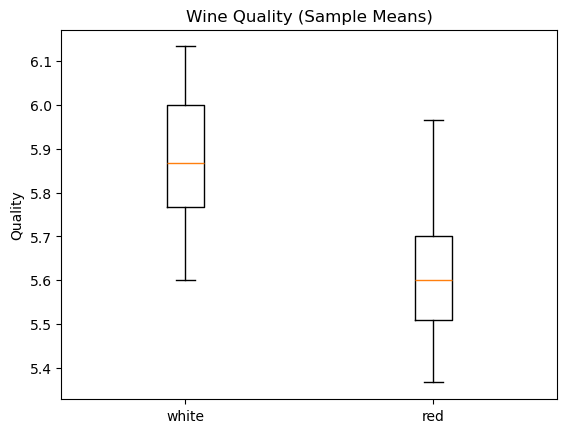

In [26]:
# check for outliers
plt.boxplot([df_means['white'], df_means['red']],
            tick_labels=['white', 'red'])
plt.title("Wine Quality (Sample Means)")
plt.ylabel('Quality')
plt.show()

In [ ]:
# shapiro-wilk normality test
print("White Wine:")
w_stat, p_value = stats.shapiro(df_means['white'])
print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

print("\nRed Wine:")
w_stat, p_value = stats.shapiro(df_means['red'])
print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

White Wine:
w_stat: 0.9715
P-value: 0.2654
Normal data

Red Wine:
w_stat: 0.9710
P-value: 0.2541
Normal data


In [28]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_white = var_red
Ha: var_white != var_red
"""
var_white = df_means['white'].var(ddof=1)
var_red = df_means['red'].var(ddof=1)

# F-statistic
if var_white > var_red:
    f_stat = var_white / var_red
else:
    f_stat = var_red / var_white

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_white = df_means['white'].count() - 1
dof_red = df_means['red'].count() - 1

# two-tailed p-value  
p_value = 2 * (1 - stats.f.cdf(f_stat, dof_white, dof_red))
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print("unequal variances")
else:
    print("equal variances")

f_stat = 1.2526
p_value = 0.4334
equal variances


In [29]:
"""
2-Sample T-Test for Independent Samples
----------------------------------------
Ho: white_quality <= red_quality
Ha: white_quality > red_quality
"""
t_stat, p_value = stats.ttest_ind(
    df_means['white'],
    df_means['red'],
    alternative='greater',
    equal_var=True 
)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print("White wine quality is better than red wine quality.")
else:
    print("There is no significant difference between white wine quality and red wine quality.")

t_stat = 9.3178
p_value = 0.0000
White wine quality is better than red wine quality.


In [30]:
"""
right-tailed test
------------------
Ho: u_white = u_red
Ha: u_white > u_red
"""
# cohen's d
white_mean = df_means['white'].mean()
red_mean = df_means['red'].mean()
white_std = df_means['white'].std(ddof=1)

d = abs((white_mean - red_mean) / white_std)
print(f"Cohen's d: {d:.4f}")

# power of the test
power = TTestPower().power(
    effect_size=d,
    nobs=df_means['white'].count(),
    alpha=0.05,
    alternative="larger"
)
print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 1.7671
Power of the test: 100.00%
